# 02 · Primer entrenamiento con los adjuntos

Este notebook sí entrena con datos reales disponibles. Estima `LN_IC50` de fármacos conocidos en líneas reservadas usando sólo `DRUG_ID` y `CANCER_TYPE`. Sirve como referencia cuantitativa antes de incorporar expresión.

Para un mismo fármaco y tipo tumoral, estas entradas no distinguen dos líneas. Por ello un resultado global alto no demostraría personalización molecular. Evaluamos la mejora frente a la **media por fármaco**, además de una media global.

El test permanece fuera de ajuste y selección. No ajustar decisiones tras mirar sus métricas. Implementación en `src/gbm_drug_response/modeling.py`; protocolo y fuentes en `docs/metodologia.md`.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "config.json").is_file() and (p / "src/gbm_drug_response").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Abra este notebook desde el repositorio gbm-drug-response.")
sys.path.insert(0, str(ROOT / "src"))
from gbm_drug_response.data import load_config
CFG = load_config(ROOT)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False})
display(CFG)

{'seed': 42,
 'target': 'LN_IC50',
 'group': 'SANGER_MODEL_ID',
 'qc_rmse_max': 0.3,
 'qc_sensitivity_thresholds': [0.15, 0.2, 0.25, 0.3],
 'test_size': 0.2,
 'cv_folds': 4,
 'metadata_features': ['DRUG_ID', 'CANCER_TYPE'],
 'molecular_drug_ids': [],
 'molecular_max_drugs': 3,
 'molecular_min_development_lines': 25,
 'molecular_min_test_lines': 5,
 'bootstrap_repetitions': 1000}

## X, y y particiones

Los IDs de línea se usan para separar conjuntos; nunca como predictores. `AUC`, `RMSE` y `Z_SCORE` quedan fuera de X, al igual que IDs de curva. La QC se aplica de nuevo a los originales con la configuración actual para no usar una tabla procesada con un umbral antiguo.

`GroupKFold` conserva cada línea completa en un solo fold de validación. El holdout persistido no aparece en los folds de desarrollo.

In [2]:
from gbm_drug_response.data import read_responses, FILES, quality_flags
from gbm_drug_response.modeling import (
    get_split, attach_split, grouped_folds, BLOCKED_FEATURES,
    metadata_candidates, train_metadata
)
raw = read_responses(ROOT / "data/raw" / FILES["glioma_csv"])
data = raw.loc[quality_flags(raw, CFG["qc_rmse_max"]).keep].copy()
dev, test = attach_split(data, get_split(ROOT, CFG))
assert not set(CFG["metadata_features"]) & BLOCKED_FEATURES
assert set(dev.SANGER_MODEL_ID).isdisjoint(test.SANGER_MODEL_ID)
display(pd.DataFrame([
    {"partition": name, "rows": len(df), "lines": df.SANGER_MODEL_ID.nunique(), "drug_ids": df.DRUG_ID.nunique()}
    for name, df in [("development", dev), ("test", test)]
]))
X_development = dev[CFG["metadata_features"]]
y_development = dev["LN_IC50"]
display(X_development.head())

,partition,rows,lines,drug_ids
0,development,9324,40,295
1,test,2677,11,295


,DRUG_ID,CANCER_TYPE
0,1003,Glioblastoma
1,1003,Glioblastoma
2,1003,Glioblastoma
3,1003,Glioma
4,1003,Glioblastoma


## Modelos y búsqueda

La media por fármaco se calcula únicamente con el entrenamiento de cada fold. Elastic Net usa codificación one-hot de las categorías. Extra Trees permite interacciones entre fármaco y tipo tumoral.

La búsqueda pequeña usa MAE en cuatro folds agrupados. El modelo elegido puede ser una referencia simple si gana en CV. No se obliga a elegir el algoritmo más complejo. Los modelos se ajustan en CPU.

In [3]:
for name, (estimator, grid) in metadata_candidates(CFG).items():
    print(name, "→", grid or "sin hiperparámetros")
cv_summary, test_metrics, predictions, run = train_metadata(ROOT)
display(cv_summary)
print("Modelo seleccionado sólo con CV de desarrollo:", run["selected_on_development_cv"])

global_mean → sin hiperparámetros
drug_mean → sin hiperparámetros
elastic_net_metadata → {'regressor__alpha': [0.001, 0.01], 'regressor__l1_ratio': [0.1, 0.5]}
extra_trees_metadata → {'regressor__min_samples_leaf': [5, 15], 'regressor__max_features': [1.0]}


,model,cv_mae,cv_fold_std,best_params
1,drug_mean,0.918844,0.056214,{}
3,extra_trees_metadata,0.937996,0.060918,"{""regressor__max_features"": 1.0, ""regressor__m..."
2,elastic_net_metadata,0.994488,0.056794,"{""regressor__alpha"": 0.001, ""regressor__l1_rat..."
0,global_mean,2.040014,0.025722,{}


Modelo seleccionado sólo con CV de desarrollo: drug_mean


## Evaluación final

`prediction_rmse` está en unidades de LN_IC50; no es el RMSE experimental del CSV.
Las métricas principales excluyen fármacos nunca observados en desarrollo y reportan cuántos son.

El promedio por fármaco (macro) asigna igual peso a cada medicamento; por línea asigna igual peso a cada modelo celular. La correlación agrupada puede reflejar principalmente diferencias entre medicamentos.

,model,n,mae,prediction_rmse,r2,spearman,macro_drug_mae,macro_line_mae
0,global_mean,2677,2.080341,2.773233,-0.000023,NaN,2.063203,2.102689
1,drug_mean,2677,0.938910,1.286945,0.784644,0.821090,0.939356,0.981006
2,elastic_net_metadata,2677,1.020580,1.354041,0.761603,0.822455,1.024406,1.058283
3,extra_trees_metadata,2677,0.957080,1.308395,0.777405,0.815552,0.955816,0.999390


Filas de test con fármacos no vistos: 0
Intervalo para el modelo seleccionado y diferencia de MAE frente a la media por fármaco:


{'n_test_lines': 11,
 'line_macro_mae': 0.9810063106356178,
 'line_macro_mae_ci95': [0.7522533499482393, 1.3556810033505862],
 'delta_vs_baseline': 0.0,
 'delta_ci95': [0.0, 0.0],
 'method': 'bootstrap agrupado por SIDM; percentil; condicionado al entrenamiento fijo'}

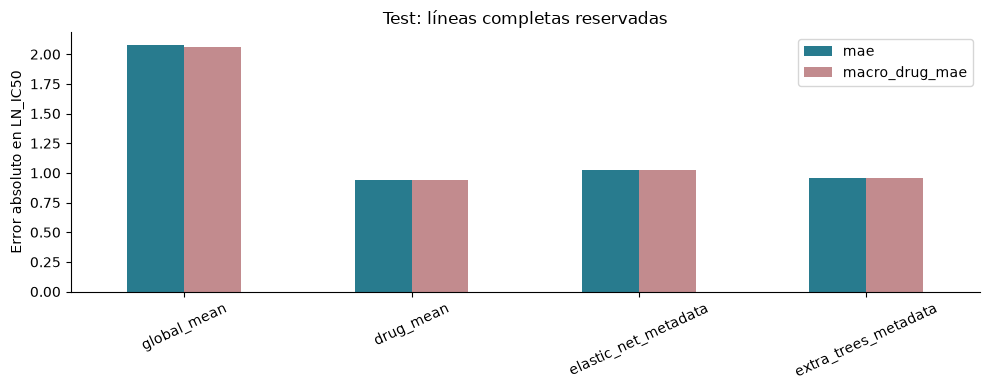

In [4]:
display(test_metrics)
print("Filas de test con fármacos no vistos:", run["unsupported_test_rows"])
print("Intervalo para el modelo seleccionado y diferencia de MAE frente a la media por fármaco:")
display(run["interval"])
fig, ax = plt.subplots()
test_metrics.set_index("model")[["mae", "macro_drug_mae"]].plot.bar(ax=ax, color=["#287b8e", "#c28b8e"])
ax.set(ylabel="Error absoluto en LN_IC50", xlabel="", title="Test: líneas completas reservadas")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## Diagnóstico por fármaco y de residuos

Compare el modelo con la media por fármaco dentro del mismo conjunto de test. Los residuos con respecto a esa referencia ayudan a distinguir potencia media del medicamento de variación entre líneas.

El intervalo bootstrap remuestrea líneas completas. Es exploratorio: hay pocas líneas reservadas y no cuantifica la variación de repetir todo el entrenamiento.

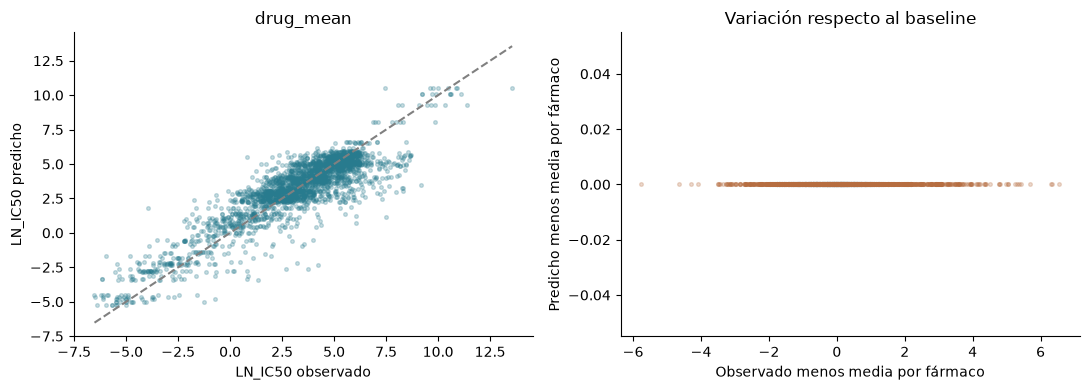

,model,DRUG_ID,DRUG_NAME,n,mae,prediction_rmse,r2,spearman
295,drug_mean,1003,Camptothecin,11,1.196964,1.501663,-0.005981,NaN
296,drug_mean,1004,Vinblastine,7,1.425234,2.074933,-0.006513,NaN
297,drug_mean,1005,Cisplatin,7,1.128021,1.242564,-0.038407,NaN
298,drug_mean,1006,Cytarabine,7,1.268088,1.419190,-0.042290,NaN
299,drug_mean,1007,Docetaxel,11,1.438617,1.597011,-0.054866,NaN
300,drug_mean,1008,Methotrexate,11,2.031967,2.515192,-0.001534,NaN
301,drug_mean,1009,Tretinoin,4,1.282680,1.828935,-0.045665,NaN
302,drug_mean,1010,Gefitinib,11,0.577063,0.921318,-0.003191,NaN
303,drug_mean,1011,Navitoclax,11,0.959054,1.310606,-0.513475,NaN
304,drug_mean,1012,Vorinostat,11,0.805751,0.924246,-0.002023,NaN


Modelo guardado en models/metadata_baseline.joblib; no reajustado con test.
Las métricas, predicciones, folds y configuración están en reports/metadata_baseline/.


In [5]:
selected = run["selected_on_development_cv"]
p = predictions.loc[predictions.drug_seen_in_training].copy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(p.LN_IC50, p[selected], s=7, alpha=0.25, color="#287b8e")
lim = [min(p.LN_IC50.min(), p[selected].min()), max(p.LN_IC50.max(), p[selected].max())]
axes[0].plot(lim, lim, "--", color="gray")
axes[0].set(xlabel="LN_IC50 observado", ylabel="LN_IC50 predicho", title=selected)
axes[1].scatter(p.LN_IC50 - p.drug_mean, p[selected] - p.drug_mean, s=7, alpha=0.25, color="#b66d40")
axes[1].set(xlabel="Observado menos media por fármaco", ylabel="Predicho menos media por fármaco",
            title="Variación respecto al baseline")
plt.tight_layout()
plt.show()
by_drug = pd.read_csv(ROOT / "reports/metadata_baseline/test_by_drug.csv")
display(by_drug.loc[by_drug.model == selected].head(15))
print("Modelo guardado en models/metadata_baseline.joblib; no reajustado con test.")
print("Las métricas, predicciones, folds y configuración están en reports/metadata_baseline/.")

## Qué concluir

Este resultado es una referencia de metadatos. Para evaluar si la expresión mejora la predicción individual, continuar con el notebook 03 y comparar con la media por fármaco en las mismas líneas emparejadas. No comparar métricas calculadas sobre cohortes distintas sin advertirlo. T98G ya forma parte de la cohorte y no constituye validación externa.

Fuentes: [QC y definiciones de Sanger](https://depmap.sanger.ac.uk/documentation/datasets/drug-sensitivity/), [GroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html), [prevención de fuga](https://scikit-learn.org/stable/common_pitfalls.html).